For this example we use Mammographic Mass dataset.

https://archive.ics.uci.edu/dataset/161/mammographic+mass

Discrimination of benign and malignant mammographic masses based on BI-RADS attributes and the patient's age.

# Environment


For this project, you can create a Python environment either with **`.venv`** or with **Conda**.

## Option 1: Create an environment with `.venv`

```bash
python -m venv .venv

.venv/bin/activate
```

## Option 2: Create an environment with Conda

You can create a Conda environment either from the command line or with Anaconda Navigator.

Using the command line


```bash
conda create -n my-env
conda activate my-env

```

Alternatively you cane use the Anaconda Navigator

# Imports
We use the following cell to import all required libraries. This cell is extended iteratively as the codebase grows.

In [39]:
from ucimlrepo import fetch_ucirepo # for Downloading datasets from UCI Machine Learning Repository
import pandas as pd # for data manipulation and analysis
import matplotlib.pyplot as plt # for data visualization
from sklearn.model_selection import train_test_split # for splitting the dataset into training and testing sets



# Load Data

There are two possible ways. Either Download the dataset and save it somewhere. Or use a library (pip install ucimlrepo) to download it directly. More Information for the direct method can be find on the website. 

## Option 1 
This is the most straightforward way to use this dataset. However, not every dataset provides such a simple structure or direct usability.

In [15]:
# fetch dataset 
mammographic_mass = fetch_ucirepo(id=161) 
  
# data (as pandas dataframes) 
X = mammographic_mass.data.features 
y = mammographic_mass.data.targets 
  
# metadata 
print("Metadata of mammographic_mass: \n", mammographic_mass.metadata) 
  
# variable information 
print("Variable information of mammographic_mass:  \n", mammographic_mass.variables) 


Metadata of mammographic_mass: 
 {'uci_id': 161, 'name': 'Mammographic Mass', 'repository_url': 'https://archive.ics.uci.edu/dataset/161/mammographic+mass', 'data_url': 'https://archive.ics.uci.edu/static/public/161/data.csv', 'abstract': "Discrimination of benign and malignant mammographic masses based on BI-RADS attributes and the patient's age.", 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 961, 'num_features': 5, 'feature_types': ['Integer'], 'demographics': ['Age'], 'target_col': ['Severity'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2007, 'last_updated': 'Thu Mar 28 2024', 'dataset_doi': '10.24432/C53K6Z', 'creators': ['Matthias Elter'], 'intro_paper': {'ID': 448, 'type': 'NATIVE', 'title': 'The prediction of breast cancer biopsy outcomes using two CAD approaches that both emphasize an intelligible decision process.', 'authors': 'M. Elter, R. Sch

## Option 2

Since the downloaded file does not include a header row, we need to assign the column names ourselves based on the information provided on the website. Missing values are marked with ?, so we also need to convert them to NaN.

In [13]:
columns = ["BI-RADS", "Age", "Shape", "Margin", "Density", "Severity"]

df = pd.read_csv(
    "Datasets/mammographic+mass/mammographic_masses.data",
    header=None,
    names=columns,
    na_values="?"
)

X = df.drop(columns="Severity")
y = df["Severity"]

# Data Insights

## Shape

In [23]:
X.shape, y.shape

((961, 5), (961, 1))

## Info (Overview)

In [25]:
X.info()
print("---------------------------------------")
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 961 entries, 0 to 960
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BI-RADS  959 non-null    float64
 1   Age      956 non-null    float64
 2   Shape    930 non-null    float64
 3   Margin   913 non-null    float64
 4   Density  885 non-null    float64
dtypes: float64(5)
memory usage: 37.7 KB
---------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 961 entries, 0 to 960
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Severity  961 non-null    int64
dtypes: int64(1)
memory usage: 7.6 KB


In [37]:
X.describe()

,BI-RADS,Age,Shape,Margin,Density
count,959.000000,956.000000,930.000000,913.000000,885.000000
mean,4.348279,55.487448,2.721505,2.796276,2.910734
std,1.783031,14.480131,1.242792,1.566546,0.380444
min,0.000000,18.000000,1.000000,1.000000,1.000000
25%,4.000000,45.000000,2.000000,1.000000,3.000000
50%,4.000000,57.000000,3.000000,3.000000,3.000000
75%,5.000000,66.000000,4.000000,4.000000,3.000000
max,55.000000,96.000000,4.000000,5.000000,4.000000


In [33]:
X.head(20)

,BI-RADS,Age,Shape,Margin,Density
0,5.0,67.0,3.0,5.0,3.0
1,4.0,43.0,1.0,1.0,NaN
2,5.0,58.0,4.0,5.0,3.0
3,4.0,28.0,1.0,1.0,3.0
4,5.0,74.0,1.0,5.0,NaN
5,4.0,65.0,1.0,NaN,3.0
6,4.0,70.0,NaN,NaN,3.0
7,5.0,42.0,1.0,NaN,3.0
8,5.0,57.0,1.0,5.0,3.0
9,5.0,60.0,NaN,5.0,1.0


In [34]:
y.head(20)

,Severity
0,1
1,1
2,1
3,0
4,1
5,0
6,0
7,0
8,1
9,1


## Missing Value Count

In [29]:
print(X.isna().sum())
print("---------------------------------------")
print(y.isna().sum())

BI-RADS     2
Age         5
Shape      31
Margin     48
Density    76
dtype: int64
---------------------------------------
Severity    0
dtype: int64


## Target Distribution

In [35]:
print(y.value_counts())
print(y.value_counts(normalize=True))

Severity
0           516
1           445
Name: count, dtype: int64
Severity
0           0.536941
1           0.463059
Name: proportion, dtype: float64


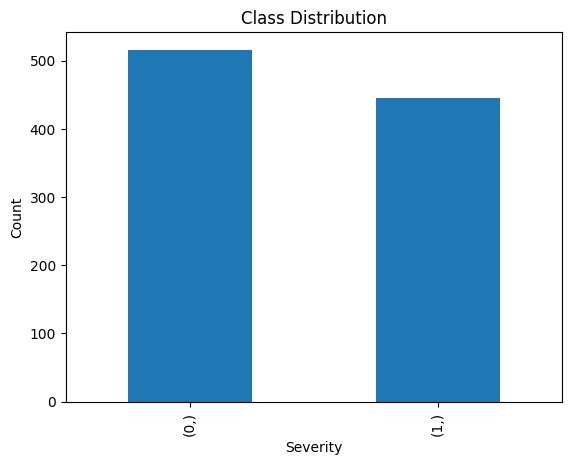

In [36]:
y.value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

# Dataset Split

In [40]:
X_train, X_val_test, y_train, y_val_test, = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [41]:
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test,
    test_size=0.50,
    random_state=42,
    stratify=y_val_test
)

In [45]:
print("y value counts normalized: \n", y.value_counts(normalize=True))
print("---------------------------------------")
print("y_train value counts normalized: \n", y_train.value_counts(normalize=True))
print("---------------------------------------")
print("y_val value counts normalized: \n", y_val.value_counts(normalize=True))
print("---------------------------------------")
print("y_test value counts normalized: \n", y_test.value_counts(normalize=True))

y value counts normalized: 
 Severity
0           0.536941
1           0.463059
Name: proportion, dtype: float64
---------------------------------------
y_train value counts normalized: 
 Severity
0           0.537202
1           0.462798
Name: proportion, dtype: float64
---------------------------------------
y_val value counts normalized: 
 Severity
0           0.534722
1           0.465278
Name: proportion, dtype: float64
---------------------------------------
y_test value counts normalized: 
 Severity
0           0.537931
1           0.462069
Name: proportion, dtype: float64
